# 7.0 — PCA on Adult Dataset

Applies PCA to the 104D OHE-encoded Adult dataset (same preprocessing as `benchmark.py`) to explore how much dimensionality can be reduced while retaining most variance.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import yaml
from sklearn.decomposition import PCA

sys.path.insert(0, str(Path('../src')))

from counterfactuals.experiments.runner import create_default_registries

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120})

In [2]:
# Load Adult dataset with the same config as benchmark.py
with open('../configs/benchmark_adult.yaml') as f:
    cfg = yaml.safe_load(f)

registries = create_default_registries()
dataset = registries['dataset'].create(cfg['dataset']['name'], **cfg['dataset']['params'])
dataset.load()

X_train, y_train = dataset.get_train()
X_test,  y_test  = dataset.get_test()

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Class balance (train): {np.bincount(y_train)}')

Train: (36178, 104)  Test: (4522, 104)
Class balance (train): [27224  8954]


## 1. Fit PCA on train, transform both splits

In [3]:
pca = PCA(n_components=None, random_state=42)   # keep all components
pca.fit(X_train)

Z_train = pca.transform(X_train)
Z_test  = pca.transform(X_test)

print(f'PCA fitted on {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Number of components: {pca.n_components_}')

PCA fitted on 36178 samples, 104 features
Number of components: 104


## 2. Explained Variance — Scree Plot

  80% variance explained by 13 components
  90% variance explained by 22 components
  95% variance explained by 31 components
  99% variance explained by 48 components


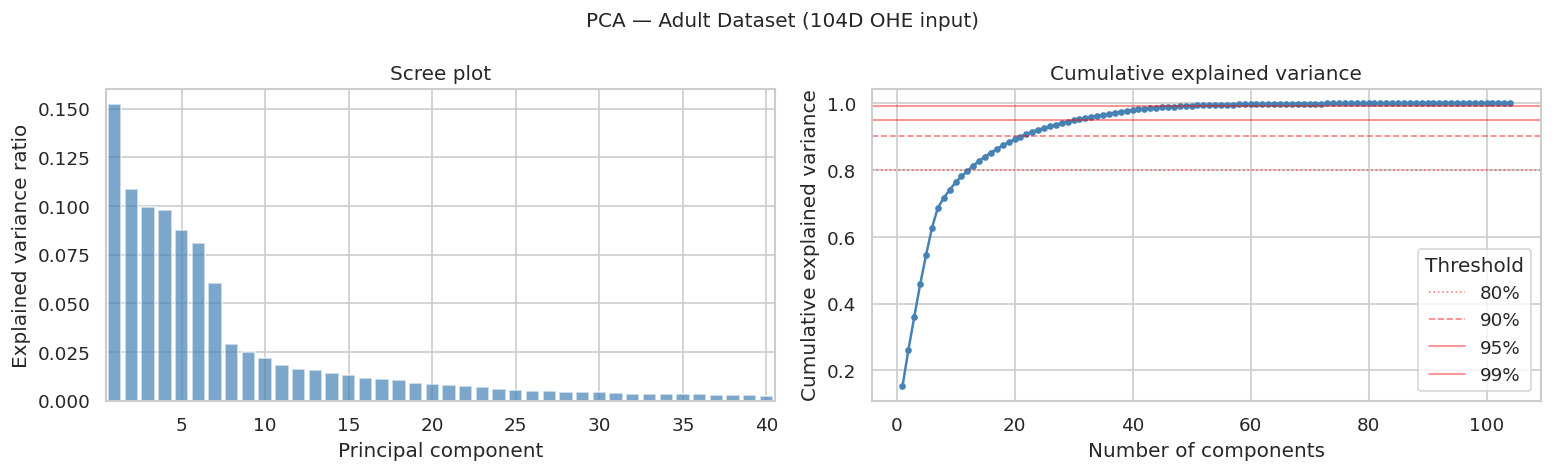

In [4]:
evr  = pca.explained_variance_ratio_
cumv = np.cumsum(evr)

# How many components for common thresholds?
for thr in (0.80, 0.90, 0.95, 0.99):
    n = int(np.searchsorted(cumv, thr)) + 1
    print(f'  {thr*100:.0f}% variance explained by {n} components')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree
axes[0].bar(range(1, len(evr) + 1), evr, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')
axes[0].set_xlim(0.5, min(40, len(evr)) + 0.5)   # show first 40

# Cumulative
axes[1].plot(range(1, len(cumv) + 1), cumv, 'o-', markersize=3, color='steelblue')
for thr, ls in ((0.80, ':'), (0.90, '--'), (0.95, '-'), (0.99, '-')):
    axes[1].axhline(thr, linestyle=ls, color='red', alpha=0.5, linewidth=1,
                    label=f'{thr*100:.0f}%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative explained variance')
axes[1].legend(title='Threshold', loc='lower right')

plt.suptitle('PCA — Adult Dataset (104D OHE input)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. 2D Projection (PC1 vs PC2)

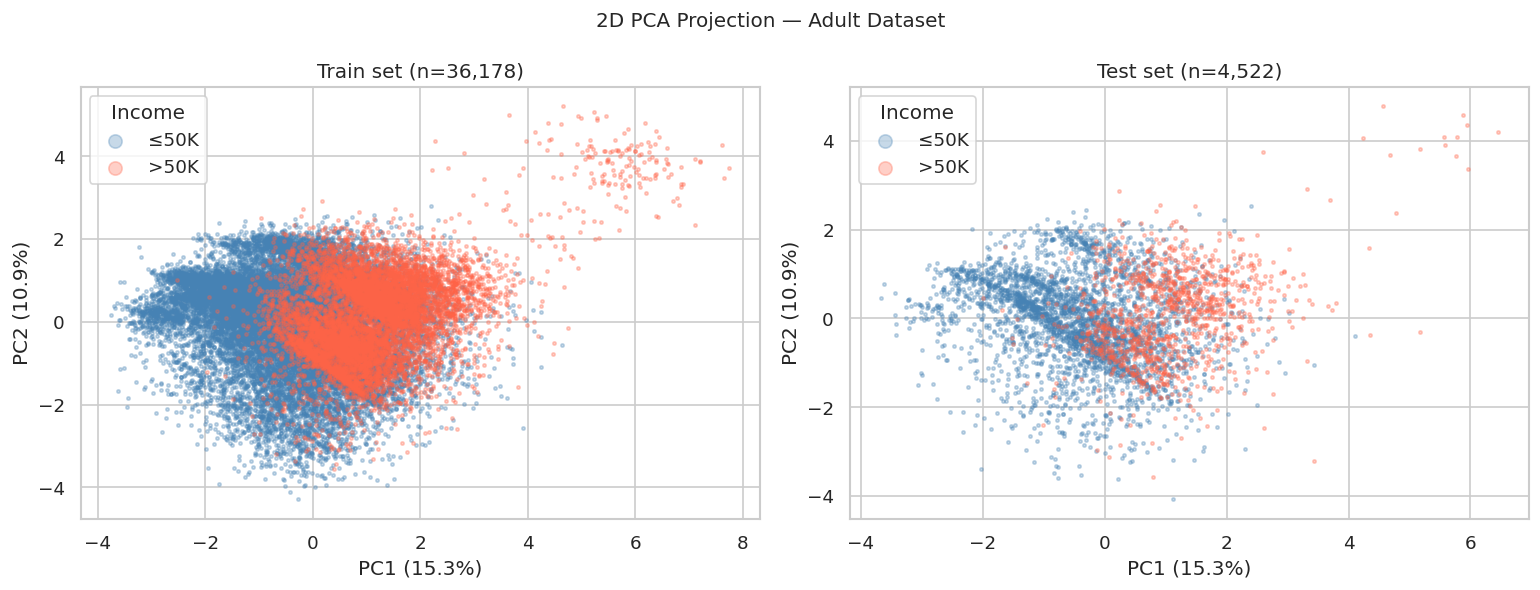

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (X_z, y, split) in zip(axes, [(Z_train, y_train, 'Train'), (Z_test, y_test, 'Test')]):
    for cls, label, color in [(0, '≤50K', 'steelblue'), (1, '>50K', 'tomato')]:
        mask = y == cls
        ax.scatter(X_z[mask, 0], X_z[mask, 1], s=4, alpha=0.3, color=color, label=label)
    ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
    ax.set_title(f'{split} set (n={len(y):,})')
    ax.legend(title='Income', markerscale=4)

plt.suptitle('2D PCA Projection — Adult Dataset', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Loadings — Which features drive the top components?

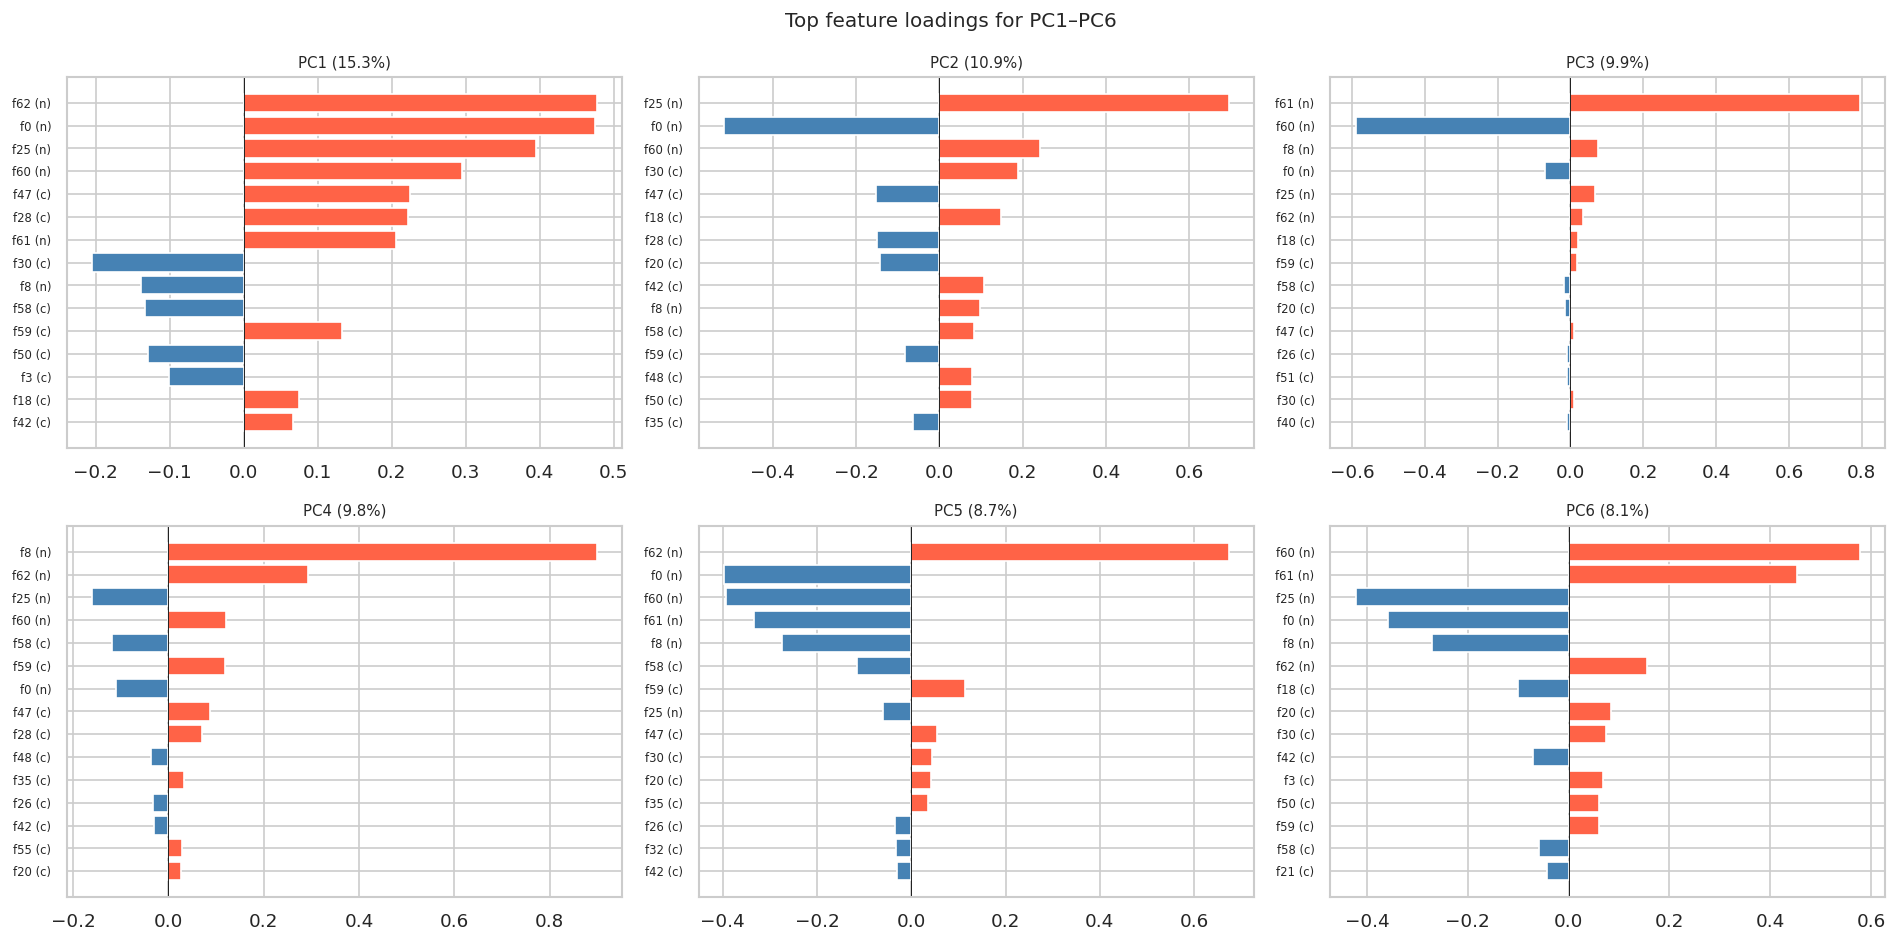

In [6]:
from training.datamodules.adult import OHE_FEATURE_TYPES as input_types

n_show = 6   # top components to inspect
n_feat_show = 15  # top features per component

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

feature_labels = [f'f{i} ({t[0]})' for i, t in enumerate(input_types)]

for k, ax in enumerate(axes[:n_show]):
    loadings = pca.components_[k]       # (104,)
    top_idx  = np.argsort(np.abs(loadings))[::-1][:n_feat_show]
    top_vals = loadings[top_idx]
    top_labs = [feature_labels[i] for i in top_idx]

    colors = ['tomato' if v > 0 else 'steelblue' for v in top_vals]
    ax.barh(range(n_feat_show), top_vals[::-1], color=colors[::-1])
    ax.set_yticks(range(n_feat_show))
    ax.set_yticklabels(top_labs[::-1], fontsize=7)
    ax.set_title(f'PC{k+1} ({evr[k]*100:.1f}%)', fontsize=9)
    ax.axvline(0, color='k', linewidth=0.5)

plt.suptitle('Top feature loadings for PC1–PC6', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Class separability vs number of components

Fit a linear classifier (logistic regression) on k PCA components and measure accuracy.
Compare against accuracy on the full 104D space.

  k=  2: test acc = 80.76%
  k=  5: test acc = 81.47%
  k= 10: test acc = 83.68%
  k= 20: test acc = 84.17%
  k= 30: test acc = 84.34%
  k= 50: test acc = 84.74%
  k= 70: test acc = 84.87%
  k=104: test acc = 84.79%


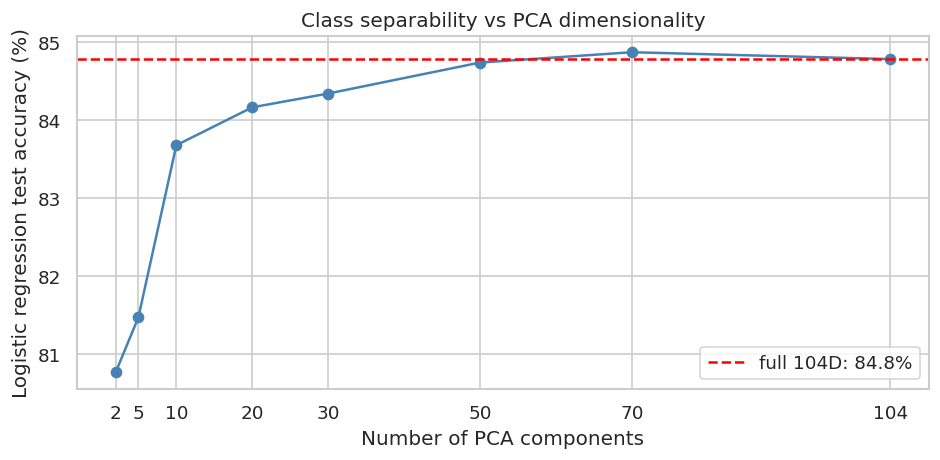

In [7]:
from sklearn.linear_model import LogisticRegression

k_values = [2, 5, 10, 20, 30, 50, 70, 104]
accs = []

for k in k_values:
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(Z_train[:, :k], y_train)
    acc = clf.score(Z_test[:, :k], y_test)
    accs.append(acc)
    print(f'  k={k:3d}: test acc = {acc*100:.2f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, [a * 100 for a in accs], 'o-', color='steelblue')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Logistic regression test accuracy (%)')
ax.set_title('Class separability vs PCA dimensionality')
ax.set_xticks(k_values)
ax.axhline(accs[-1] * 100, color='red', linestyle='--', label=f'full 104D: {accs[-1]*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Summary

Prints the component counts for common variance thresholds and the accuracy plateau.

In [8]:
print('=== Variance thresholds ===')
for thr in (0.80, 0.90, 0.95, 0.99):
    n = int(np.searchsorted(cumv, thr)) + 1
    var_n = cumv[n - 1]
    print(f'  {thr*100:.0f}%: {n:3d} components  (actual: {var_n*100:.2f}%)')

print('\n=== Logistic regression accuracy plateau ===')
plateau_thr = accs[-1] * 0.999   # within 0.1% of full-dim accuracy
for k, a in zip(k_values, accs):
    if a >= plateau_thr:
        print(f'  Plateau (within 0.1% of full 104D) reached at k={k}')
        break

=== Variance thresholds ===
  80%:  13 components  (actual: 81.26%)
  90%:  22 components  (actual: 90.67%)
  95%:  31 components  (actual: 95.17%)
  99%:  48 components  (actual: 99.05%)

=== Logistic regression accuracy plateau ===
  Plateau (within 0.1% of full 104D) reached at k=50
